Zadanie 9

Stwórz sklearn Pipeline z StandardScaler + PCA + LogisticRegression.

Dataset: Digits

Wymagania:
- Pipeline z 3 krokami
- Cross-validation na całym pipeline
- Porównaj z modelem bez PCA

RAPORT KOŃCOWY: PORÓWNANIE METRYK ACCURACY
Średnia accuracy (z PCA + Shuffle):    96.7722%
Średnia accuracy (z PCA + No Shuffle): 91.1535%
--------------------------------------------------
Średnia accuracy (bez PCA + Shuffle):    97.1066%
Średnia accuracy (bez PCA + No Shuffle): 92.0449%


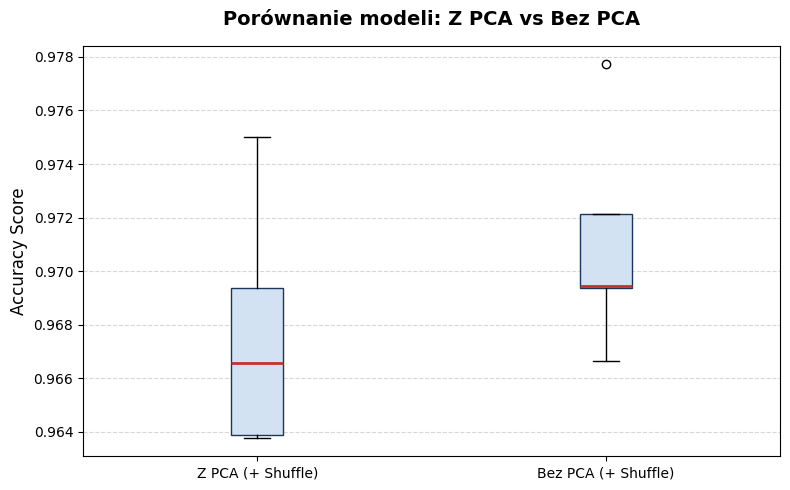

In [ ]:
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt

# Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target

# Definicja Pipeline z 3 krokami (Scaler + PCA + Model)
pipeline_with_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),    # Zachowanie 95 % informacji
    ('logistic', LogisticRegression(random_state=42, max_iter=1000)) # Wyższy max_iter zapobiega błędom zbieżności
])

# Definicja modelu bazowego (bez PCA)
pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42, max_iter=1000))
])

# Definicja obiektu walidacji z mieszaniem (shuffle)
skf_shuffle = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Wariant z PCA
# Wynik z mieszaniem
scores_pca_shuffle = cross_val_score(pipeline_with_pca, X, y, cv=skf_shuffle)

# Wynik bez mieszania (uproszczone cv=5)
scores_pca_noshuffle = cross_val_score(pipeline_with_pca, X, y, cv=5)

# Warianty bez PCA
scores_nopca_shuffle = cross_val_score(pipeline_no_pca, X, y, cv=skf_shuffle)
scores_nopca_noshuffle = cross_val_score(pipeline_no_pca, X, y, cv=5)

# Generowanie czytelnego raportu wynikowego
print("=" * 50)
print("RAPORT KOŃCOWY: PORÓWNANIE METRYK ACCURACY")
print("=" * 50)
print(f"Średnia accuracy (z PCA + Shuffle):    {scores_pca_shuffle.mean():.4%}")
print(f"Średnia accuracy (z PCA + No Shuffle): {scores_pca_noshuffle.mean():.4%}")
print("-" * 50)
print(f"Średnia accuracy (bez PCA + Shuffle):    {scores_nopca_shuffle.mean():.4%}")
print(f"Średnia accuracy (bez PCA + No Shuffle): {scores_nopca_noshuffle.mean():.4%}")
print("=" * 50)

# Wizualizacja

# Przygotowanie danych do wykresu (wybranie wariantów z mieszaniem dla sprawiedliwego porównania)
data_to_plot = [scores_pca_shuffle, scores_nopca_shuffle]
labels = ['Z PCA (+ Shuffle)', 'Bez PCA (+ Shuffle)']

# Tworzenie wykresu
plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, tick_labels=labels, patch_artist=True, 
            boxprops=dict(facecolor='#D3E2F2', color='#1A365D'),
            medianprops=dict(color='#C53030', linewidth=2))

# Dodanie elementów opisowych
plt.title('Porównanie modeli: Z PCA vs Bez PCA', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Wyświetlenie wykresu
plt.tight_layout()
plt.show()

RAPORT KOŃCOWY: PORÓWNANIE METRYK ACCURACY
Średnia accuracy (z PCA + Shuffle):    96.7722%
Średnia accuracy (z PCA + No Shuffle): 91.1535%
--------------------------------------------------
Średnia accuracy (bez PCA + Shuffle):    97.1066%
Średnia accuracy (bez PCA + No Shuffle): 92.0449%
Średni czas (z PCA + Shuffle):   1.2738 s
Średni czas (z PCA + No Shuffle): 1.9389 s
Średni czas (bez PCA + Shuffle):   1.9389 s
Średni czas (bez PCA + No Shuffle): 0.8506 s


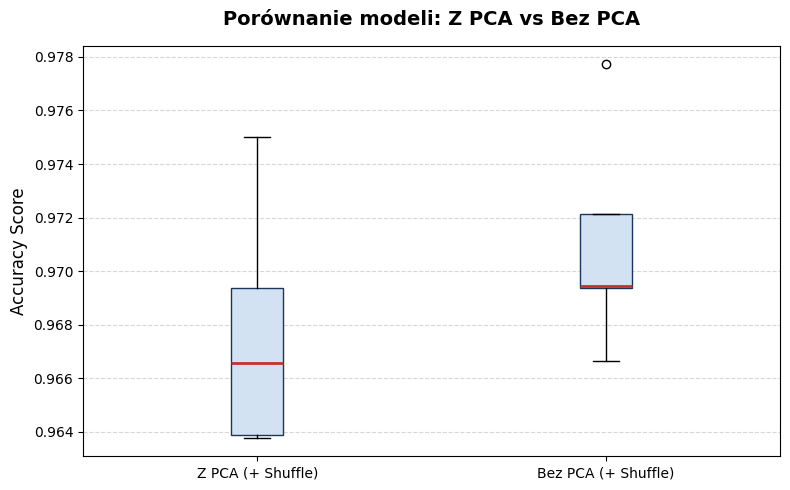

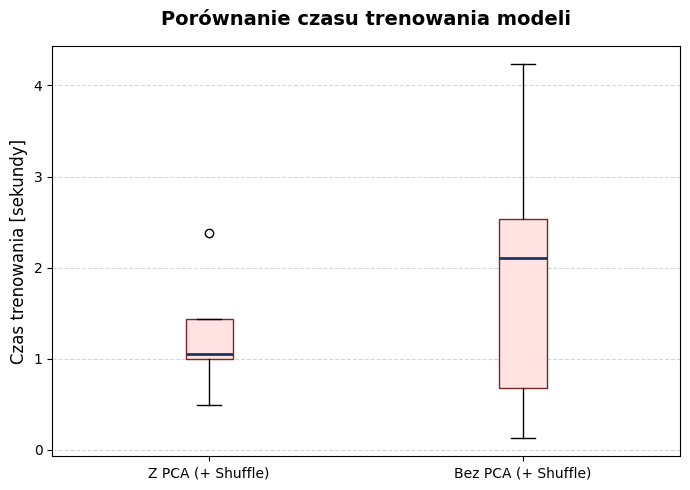

In [ ]:
# Zastosowano cross_validate zamiast cross_val_score, aby uzyskać dostęp do:
# metryk dokładności (test_score) i czasów trenowania (fit_time) potrzebnych do wykresu boxplot

from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold, cross_validate
import matplotlib.pyplot as plt

# Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target

# Definicja Pipeline z 3 krokami (Scaler + PCA + Model)
pipeline_with_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),    # Zachowanie 95 % informacji
    ('logistic', LogisticRegression(random_state=42, max_iter=1000)) # Wyższy max_iter zapobiega błędom zbieżności
])

# Definicja modelu bazowego (bez PCA)
pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42, max_iter=1000))
])

# Definicja obiektu walidacji z mieszaniem (shuffle)
skf_shuffle = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Wariant z PCA
# Wynik z mieszaniem
scores_pca_shuffle = cross_validate(pipeline_with_pca, X, y, cv=skf_shuffle)

# Wynik bez mieszania (uproszczone cv=5)
scores_pca_noshuffle = cross_validate(pipeline_with_pca, X, y, cv=5)

# Warianty bez PCA
scores_nopca_shuffle = cross_validate(pipeline_no_pca, X, y, cv=skf_shuffle)
scores_nopca_noshuffle = cross_validate(pipeline_no_pca, X, y, cv=5)

# Wyciągnięcie dokładności (accuracy)
accuracy_pca_shuffle = scores_pca_shuffle['test_score']
accuracy_pca_noshuffle = scores_pca_noshuffle['test_score']

accuracy_nopca_shuffle = scores_nopca_shuffle['test_score']
accuracy_nopca_noshuffle = scores_nopca_noshuffle['test_score']

# Wyciągnięcie czasów trenowania (fit_time)
times_pca_shuffle = scores_pca_shuffle['fit_time']
times_pca_noshuffle = scores_nopca_shuffle['fit_time']

times_nopca_shuffle = scores_nopca_shuffle['fit_time']
times_nopca_noshuffle = scores_nopca_noshuffle['fit_time']

# Generowanie czytelnego raportu wynikowego
print("=" * 50)
print("RAPORT KOŃCOWY: PORÓWNANIE METRYK ACCURACY")
print("=" * 50)
print(f"Średnia accuracy (z PCA + Shuffle):    {accuracy_pca_shuffle.mean():.4%}")
print(f"Średnia accuracy (z PCA + No Shuffle): {accuracy_pca_noshuffle.mean():.4%}")
print("-" * 50)
print(f"Średnia accuracy (bez PCA + Shuffle):    {accuracy_nopca_shuffle.mean():.4%}")
print(f"Średnia accuracy (bez PCA + No Shuffle): {accuracy_nopca_noshuffle.mean():.4%}")
print("=" * 50)
print(f"Średni czas (z PCA + Shuffle):   {times_pca_shuffle.mean():.4f} s")
print(f"Średni czas (z PCA + No Shuffle): {times_pca_noshuffle.mean():.4f} s")
print("=" * 50)
print(f"Średni czas (bez PCA + Shuffle):   {times_nopca_shuffle.mean():.4f} s")
print(f"Średni czas (bez PCA + No Shuffle): {times_nopca_noshuffle.mean():.4f} s")
print("=" * 50)

# Wizualizacja

# Przygotowanie danych do wykresu (wybranie wariantów z mieszaniem dla sprawiedliwego porównania)
data_to_plot = [accuracy_pca_shuffle, accuracy_nopca_shuffle]
labels = ['Z PCA (+ Shuffle)', 'Bez PCA (+ Shuffle)']

# Tworzenie wykresu
plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, tick_labels=labels, patch_artist=True, 
            boxprops=dict(facecolor='#D3E2F2', color='#1A365D'),
            medianprops=dict(color='#C53030', linewidth=2))

# Dodanie elementów opisowych
plt.title('Porównanie modeli: Z PCA vs Bez PCA', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Wyświetlenie wykresu
plt.tight_layout()
plt.show()

# Generowanie wykresu pudełkowego czasu trenowania
plt.figure(figsize=(7, 5))
plt.boxplot([times_pca_shuffle, times_nopca_shuffle], 
            tick_labels=['Z PCA (+ Shuffle)', 'Bez PCA (+ Shuffle)'], 
            patch_artist=True,
            boxprops=dict(facecolor='#FFE3E3', color='#742A2A'),
            medianprops=dict(color='#1A365D', linewidth=2))


plt.title('Porównanie czasu trenowania modeli', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Czas trenowania [sekundy]', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Wyświetlenie wykresu
plt.tight_layout()
plt.show()